In [1]:
import torch
from torch.utils.data import DataLoader
import numpy as np
import pickle
import pandas as pd
from pathlib import Path

import networkx as nx

import matplotlib.pyplot as plt

from matplotlib.colors import PowerNorm
from matplotlib.colors import LogNorm
import matplotlib.ticker as mticker
from matplotlib.colors import LinearSegmentedColormap

from matrix_processing_helpers import sparsify_global_percentile
from plot_helpers import plot_rollout_graph, plot_feature_ranking_comparison

### Load data

In [2]:
# results_local = np.load("Results_TR/attention_rollout_local/rollout.npz")

with open("data_processed/dataframes/input_cols_pruned.pkl", "rb") as f:
    INPUT_COLS_PRUNED = pickle.load(f)

feature_names = list(INPUT_COLS_PRUNED)

In [3]:
feature_names_short = ['1,5-Anhydrosorbitol', '2-Aminobutyric \n acid', '2-Hydroxybutyric \n acid', 
                       '2-Oxoglutaric \n acid', '3-Hydroxyisobutyric \n acid', 'Acetic \n acid', 
                       'Acetoacetic \n acid', 'Acetone', 'Alanine', 'Albumin', 
                       'Apolipoprotein B', 'Arginine', 'Asparagine', 'Aspartate', 
                       'BCAA to AAA \n ratio', 'Betaine', 'Bilirubin', 'C reactive \n protein', 
                       'Calcium', 'Choline', 'Citric \n acid', 'Creatine', 'Creatinine', 
                       'Cystine', 'D-Galactose', 'Dimethylamine', 'Dimethylsulfone', 
                       'Erythrocyte \n sedimentation \n rate', 'Erythrocytes', 
                       'Estimated \n Glomerular \n Filtration \n Rate', 'Ethanol', 'Formic acid', 
                       'Glucose', 'Glutamic \n acid', 'Glutamine', 
                       'Glutamine to \n glutamate ratio', 'Glyc A', 'GlycB to \n GlycA ratio', 
                       'Glycerol', 'Glycine', 'HDL cholesterol', 'Histidine', 'Iron', 
                       'LDL cholesterol', 'Lactate to \n pyruvate ratio', 'Lactic acid', 
                       'Leucine', 'Leukocytes', 'Lipoprotein(a)', 'Lysine', 
                       'Methanol', 'Methionine', 'Myo-inositol', 'N,N-Dimethylglycine', 
                       'Non-albumin \n protein', 'Ornithine', 'Phenylalanine', 'Platelets', 
                       'Proline', 'Pyruvic \n acid', 'SPC', 'Sarcosine', 'Serine', 
                       'Succinic \n acid', 'Threonine', 'Transferrin', 'Triglycerides', 
                       'Trimethylamine-N-oxide', 'Tyrosine', 'Urate', 'Urea', 
                       'Urea to creatinine \n ratio']

In [4]:
feature_abbrev = ["1,5-AG", "2-AB", "2-HB", "2-OG", "3-HIB", "Acetate", "AcAc", "Acetone", 
                  "Ala", "Alb", "ApoB", "Arg", "Asn", "Asp", "BCAA/AAA", "Bet", "Bili", 
                  "CRP", "Ca", "Cho", "Citrate", "Crn", "Creat", "Cys-Cys", "Gal", 
                  "DMA", "DMSO2", "ESR", "RBC", "eGFR", "EtOH", "Formate", "Gluc", "Glu-ac", 
                  "Gln", "Gln/Glu", "GlycA", "GlycB/A", "Glyc", "Gly", "HDL-C", "His", "Fe", 
                  "LDL-C", "Lac/Pyr", "Lac", "Leu", "WBC", "Lp(a)", "Lys", "MeOH", "Met", 
                  "MI", "DMG", "NAP", "Orn", "Phe", "Plt", "Pro", "Pyr", "SPC", "Sar", 
                  "Ser", "Succ", "Thr", "Tf", "TG", "TMAO", "Tyr", "Urate", "Urea", "Urea/Cr"]

### Attention matrices

In [5]:
ROLL_LOC = Path("Results/rollout_local")
ROLL_GLOB = Path("Results/rollout_global")
FIG_DIR = Path("Results/attention_plots")

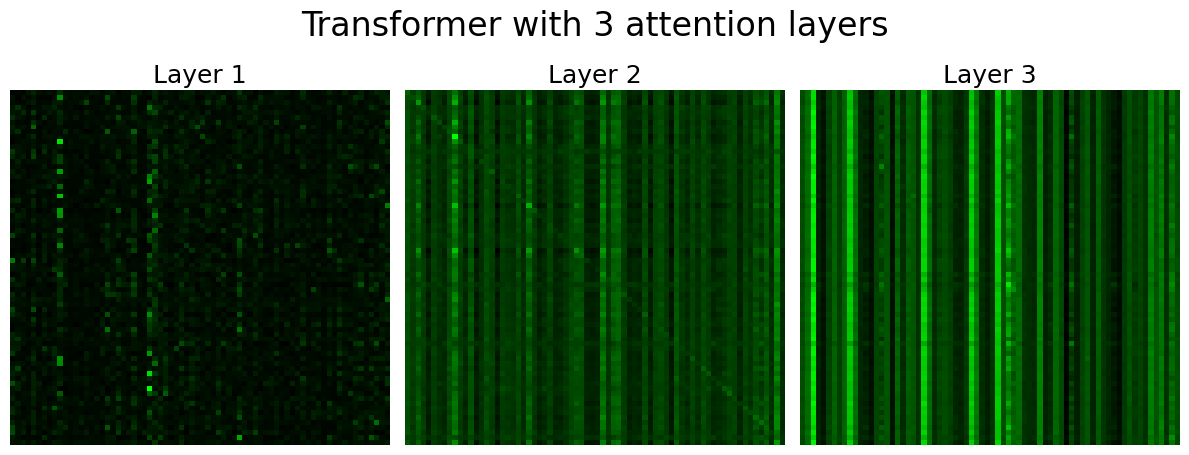

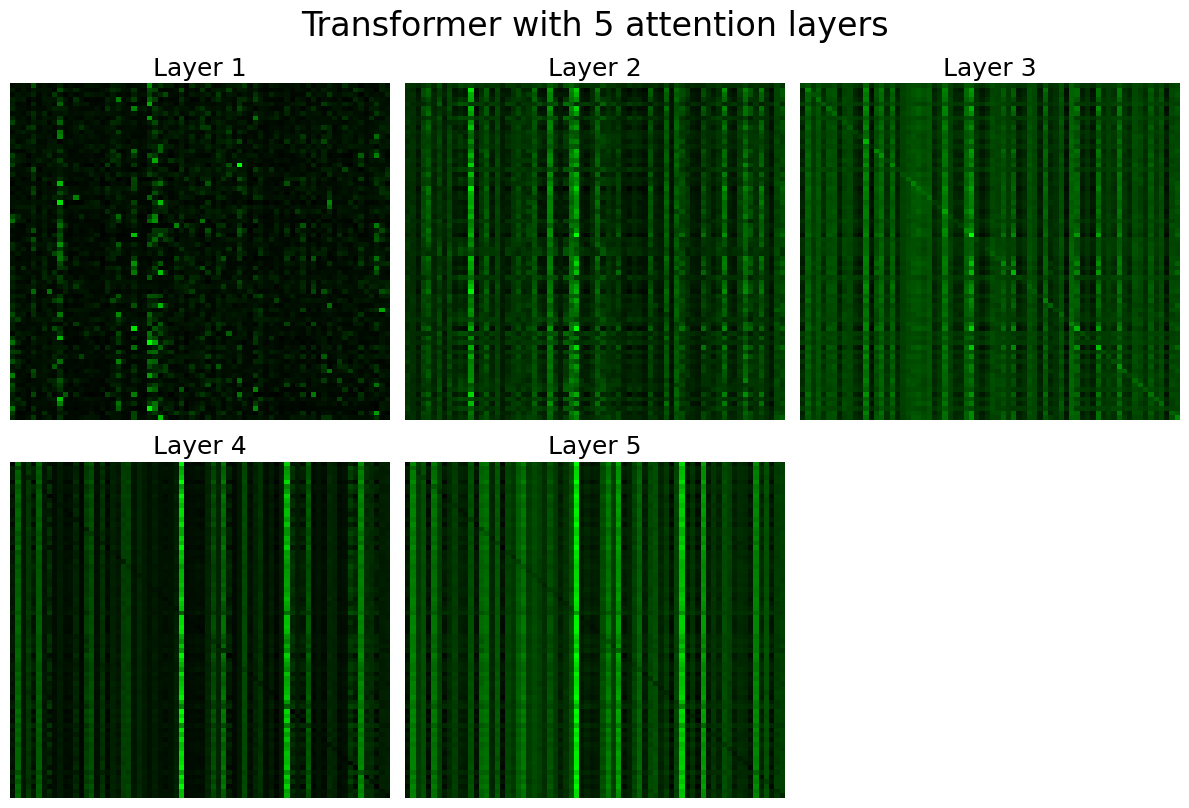

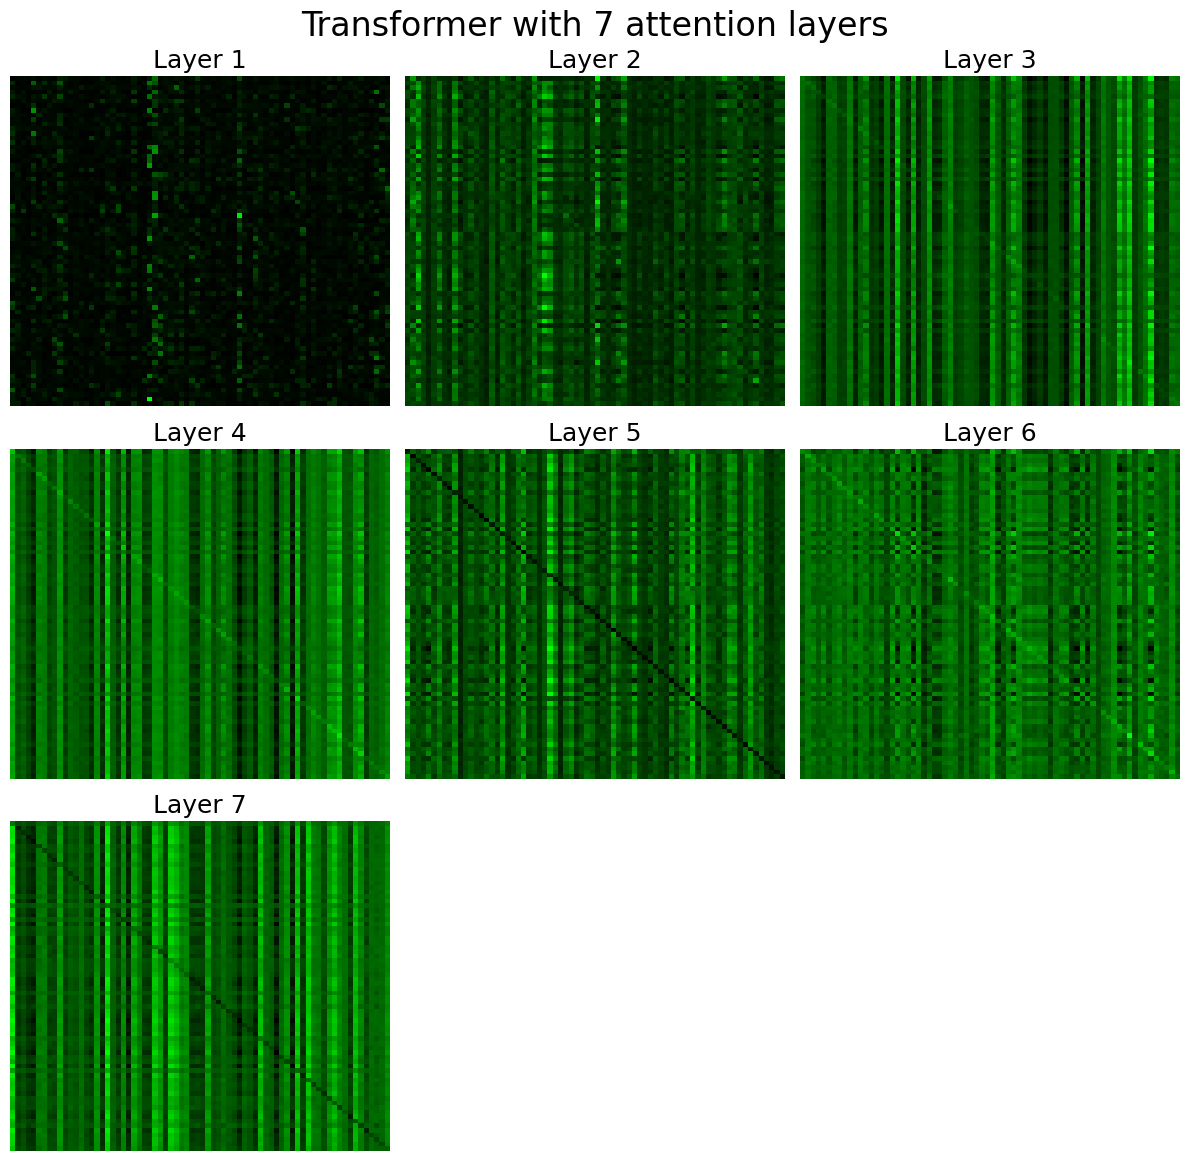

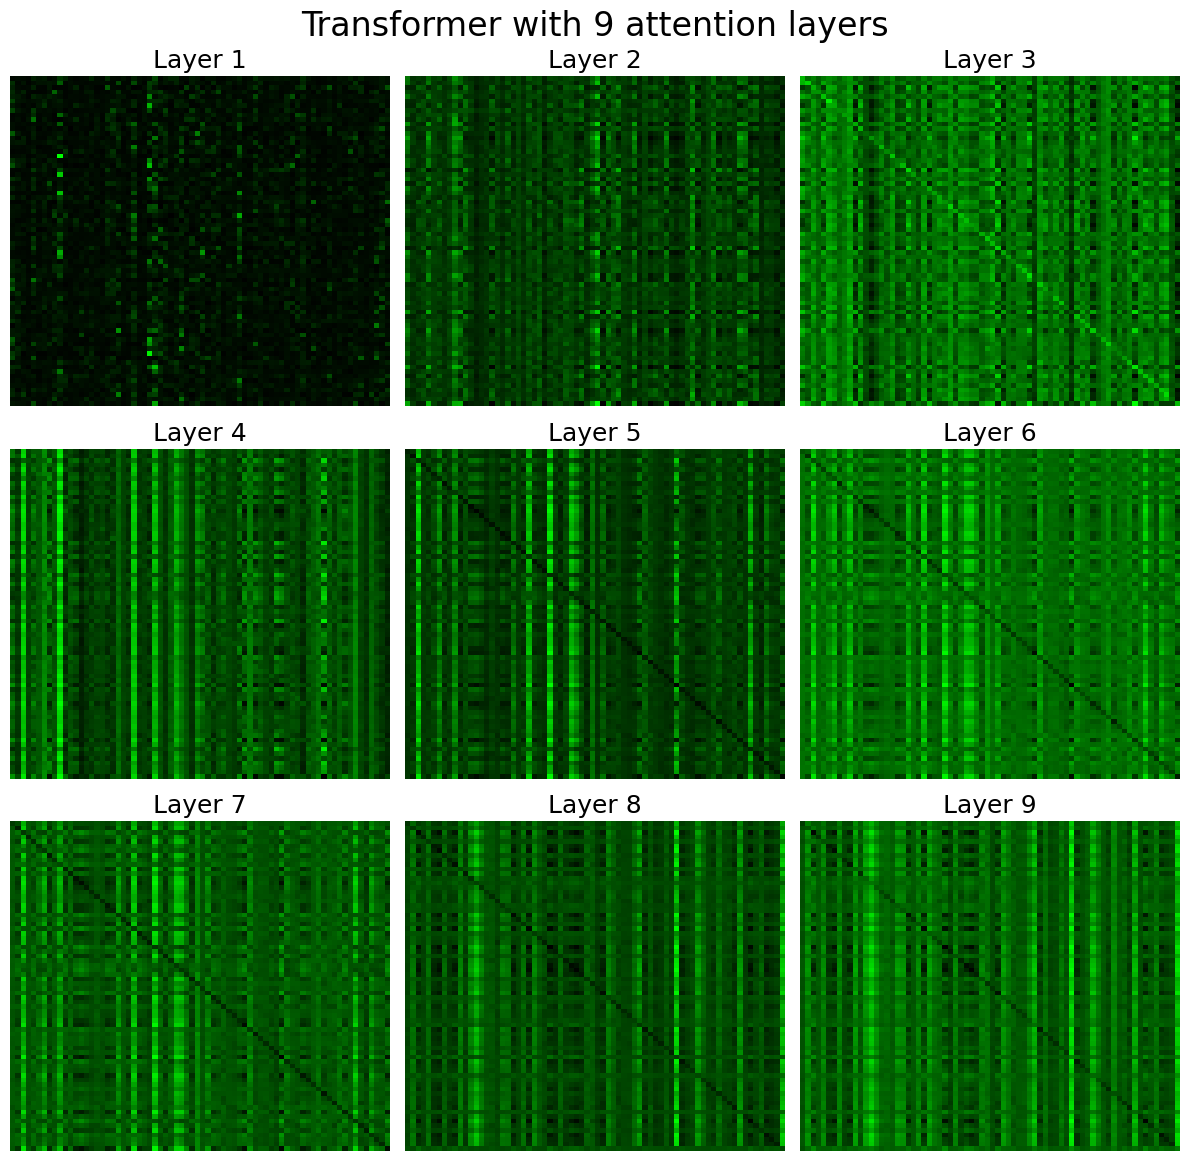

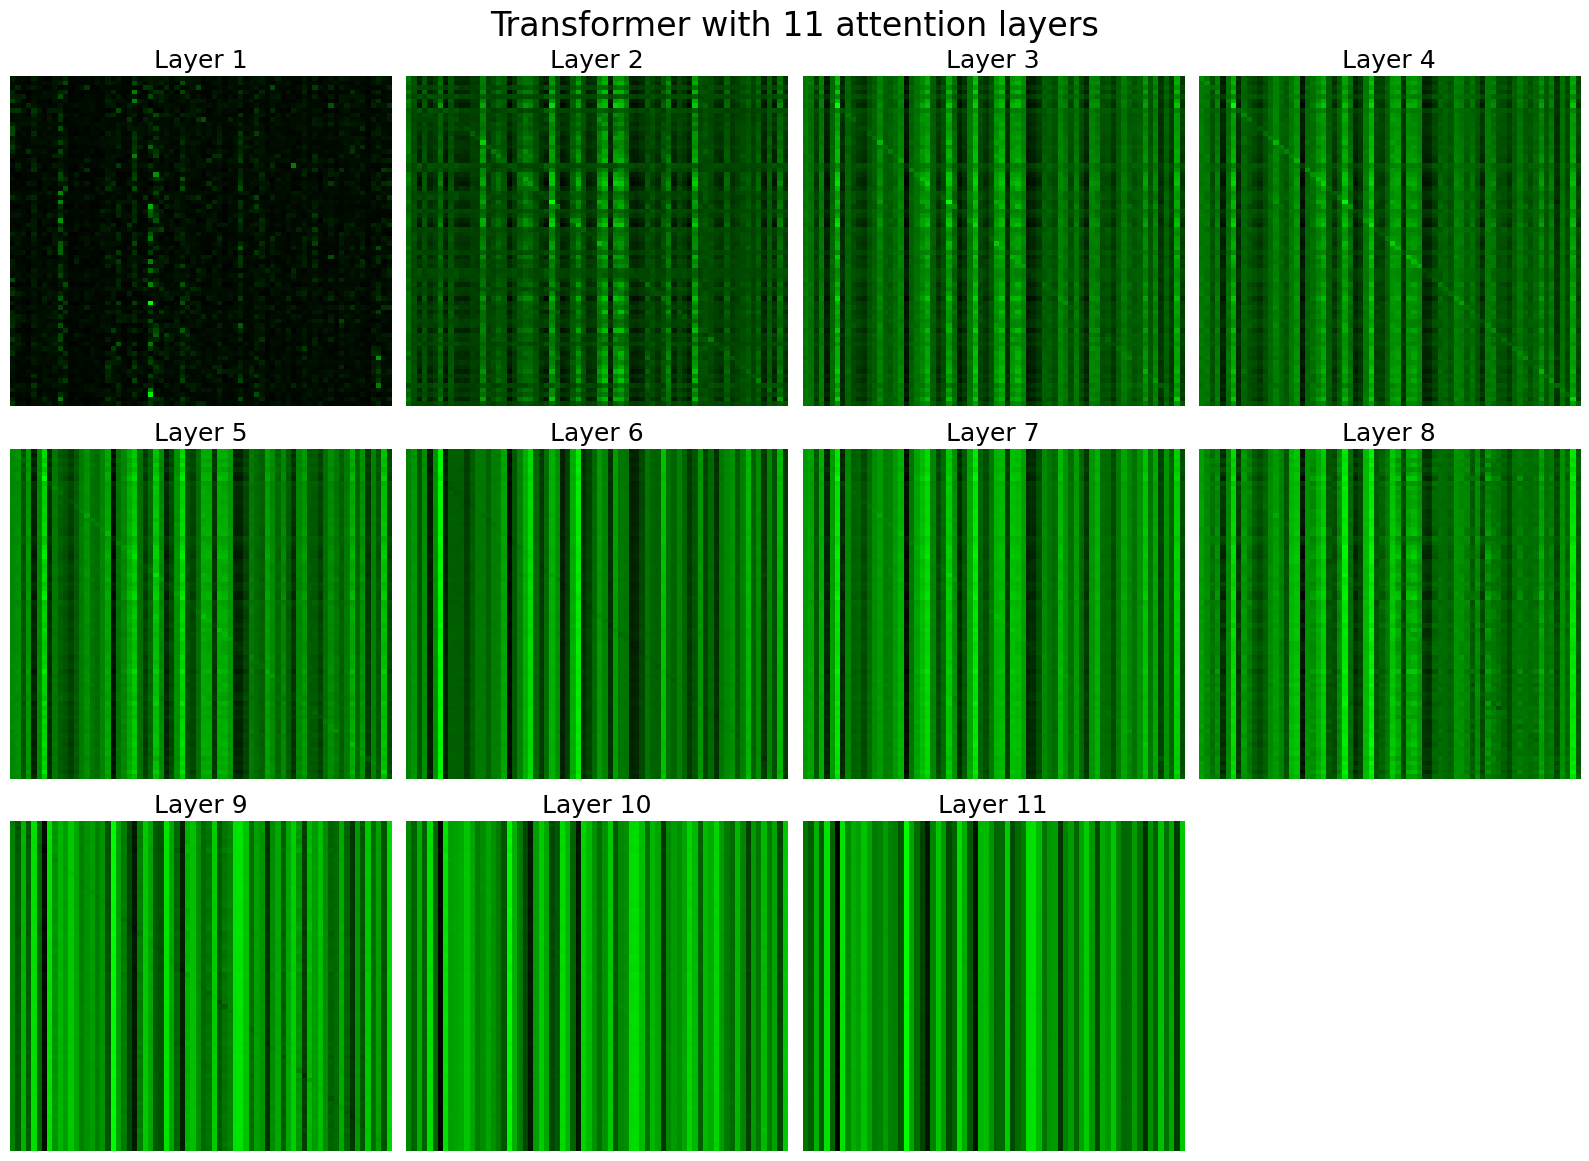

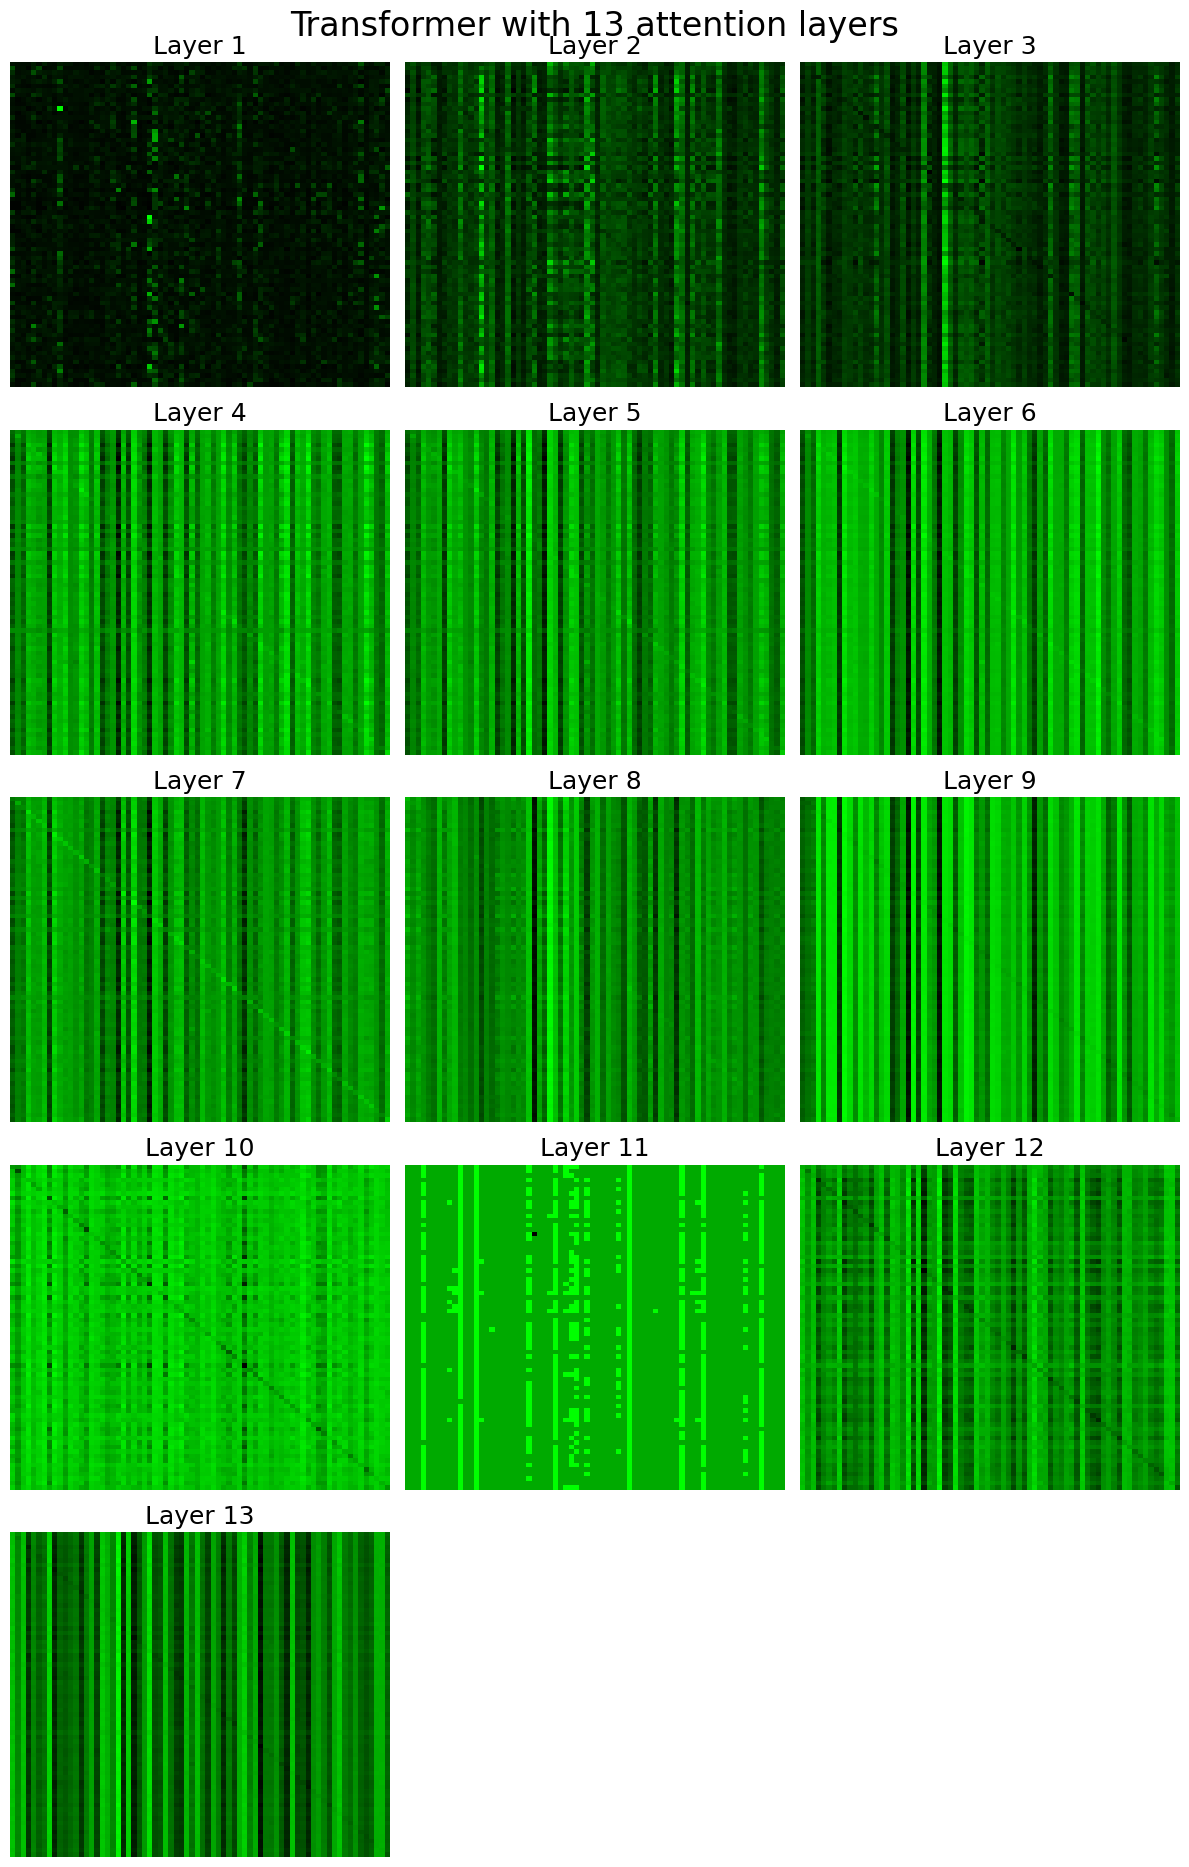

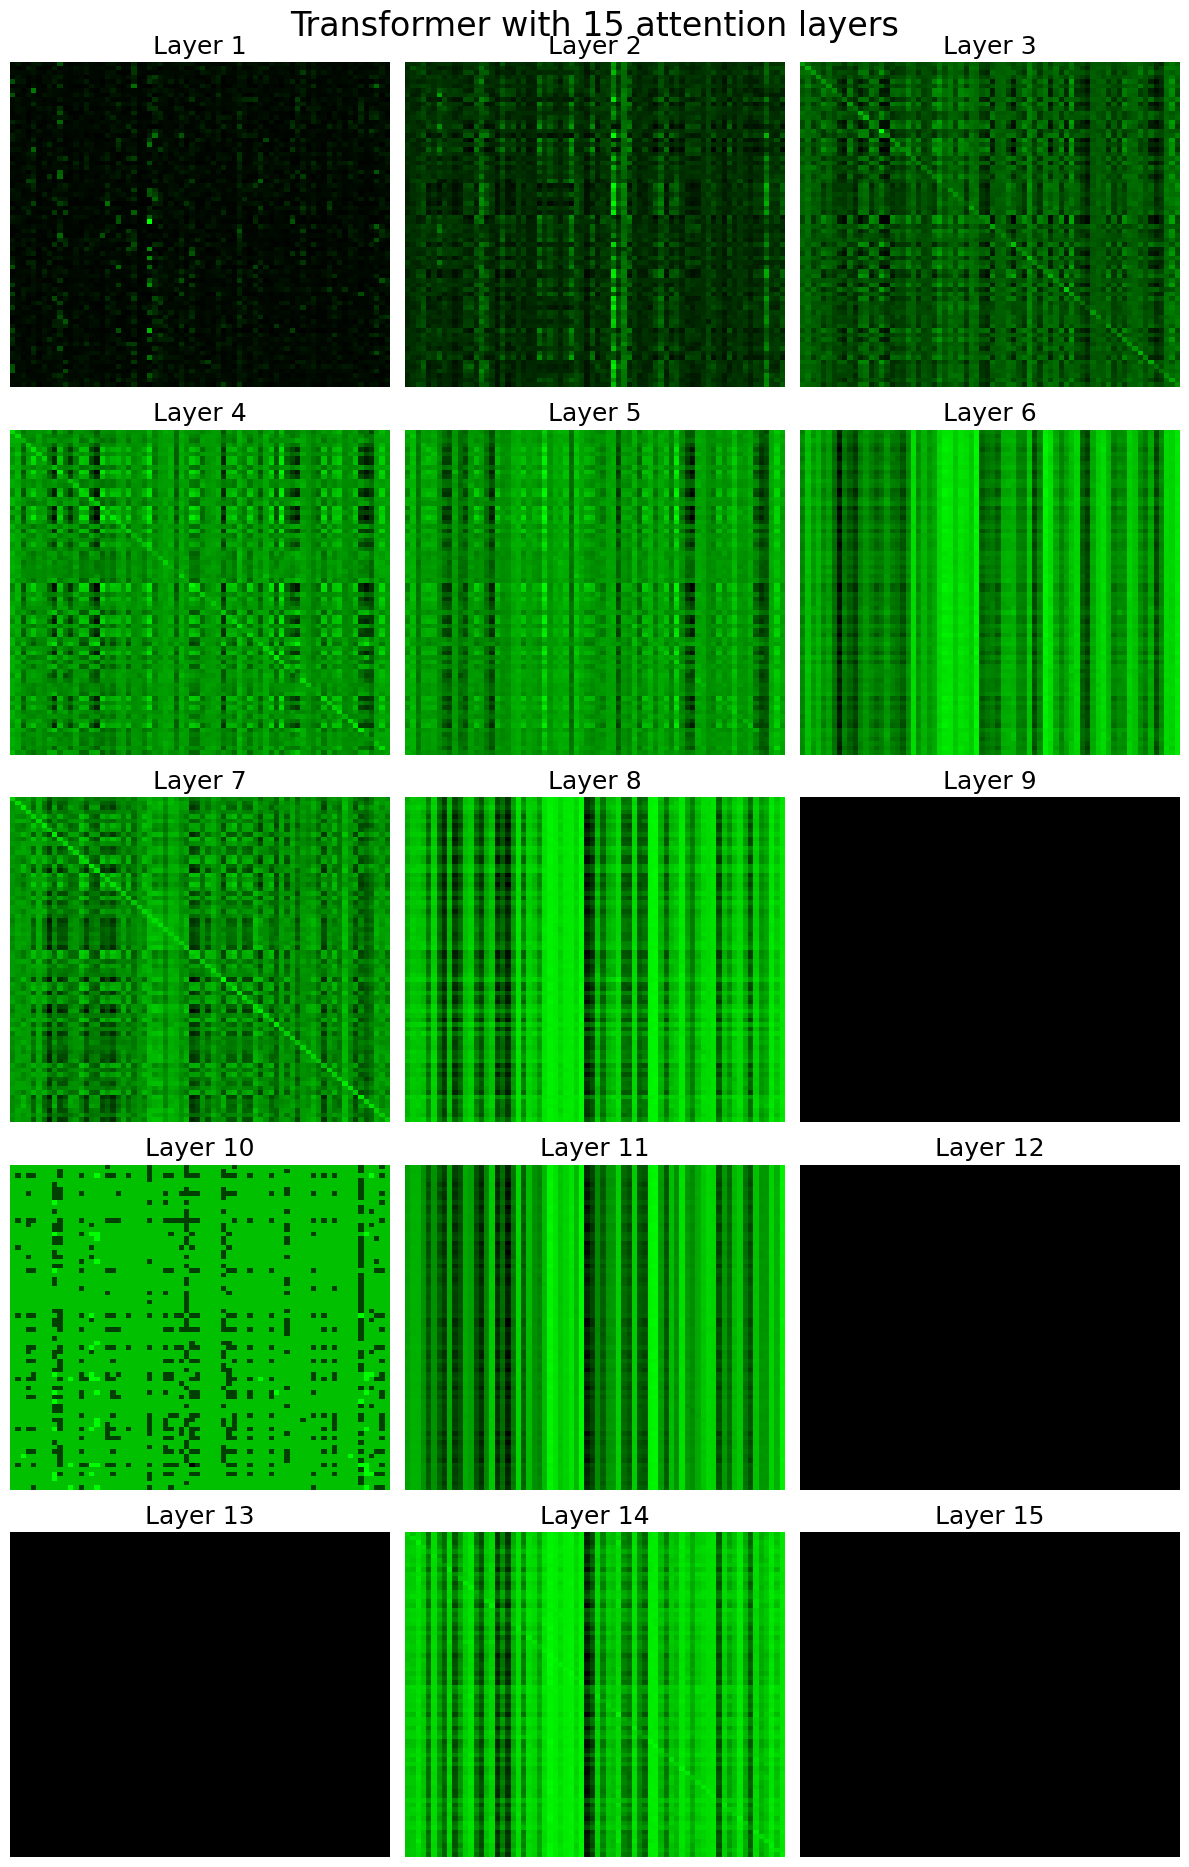

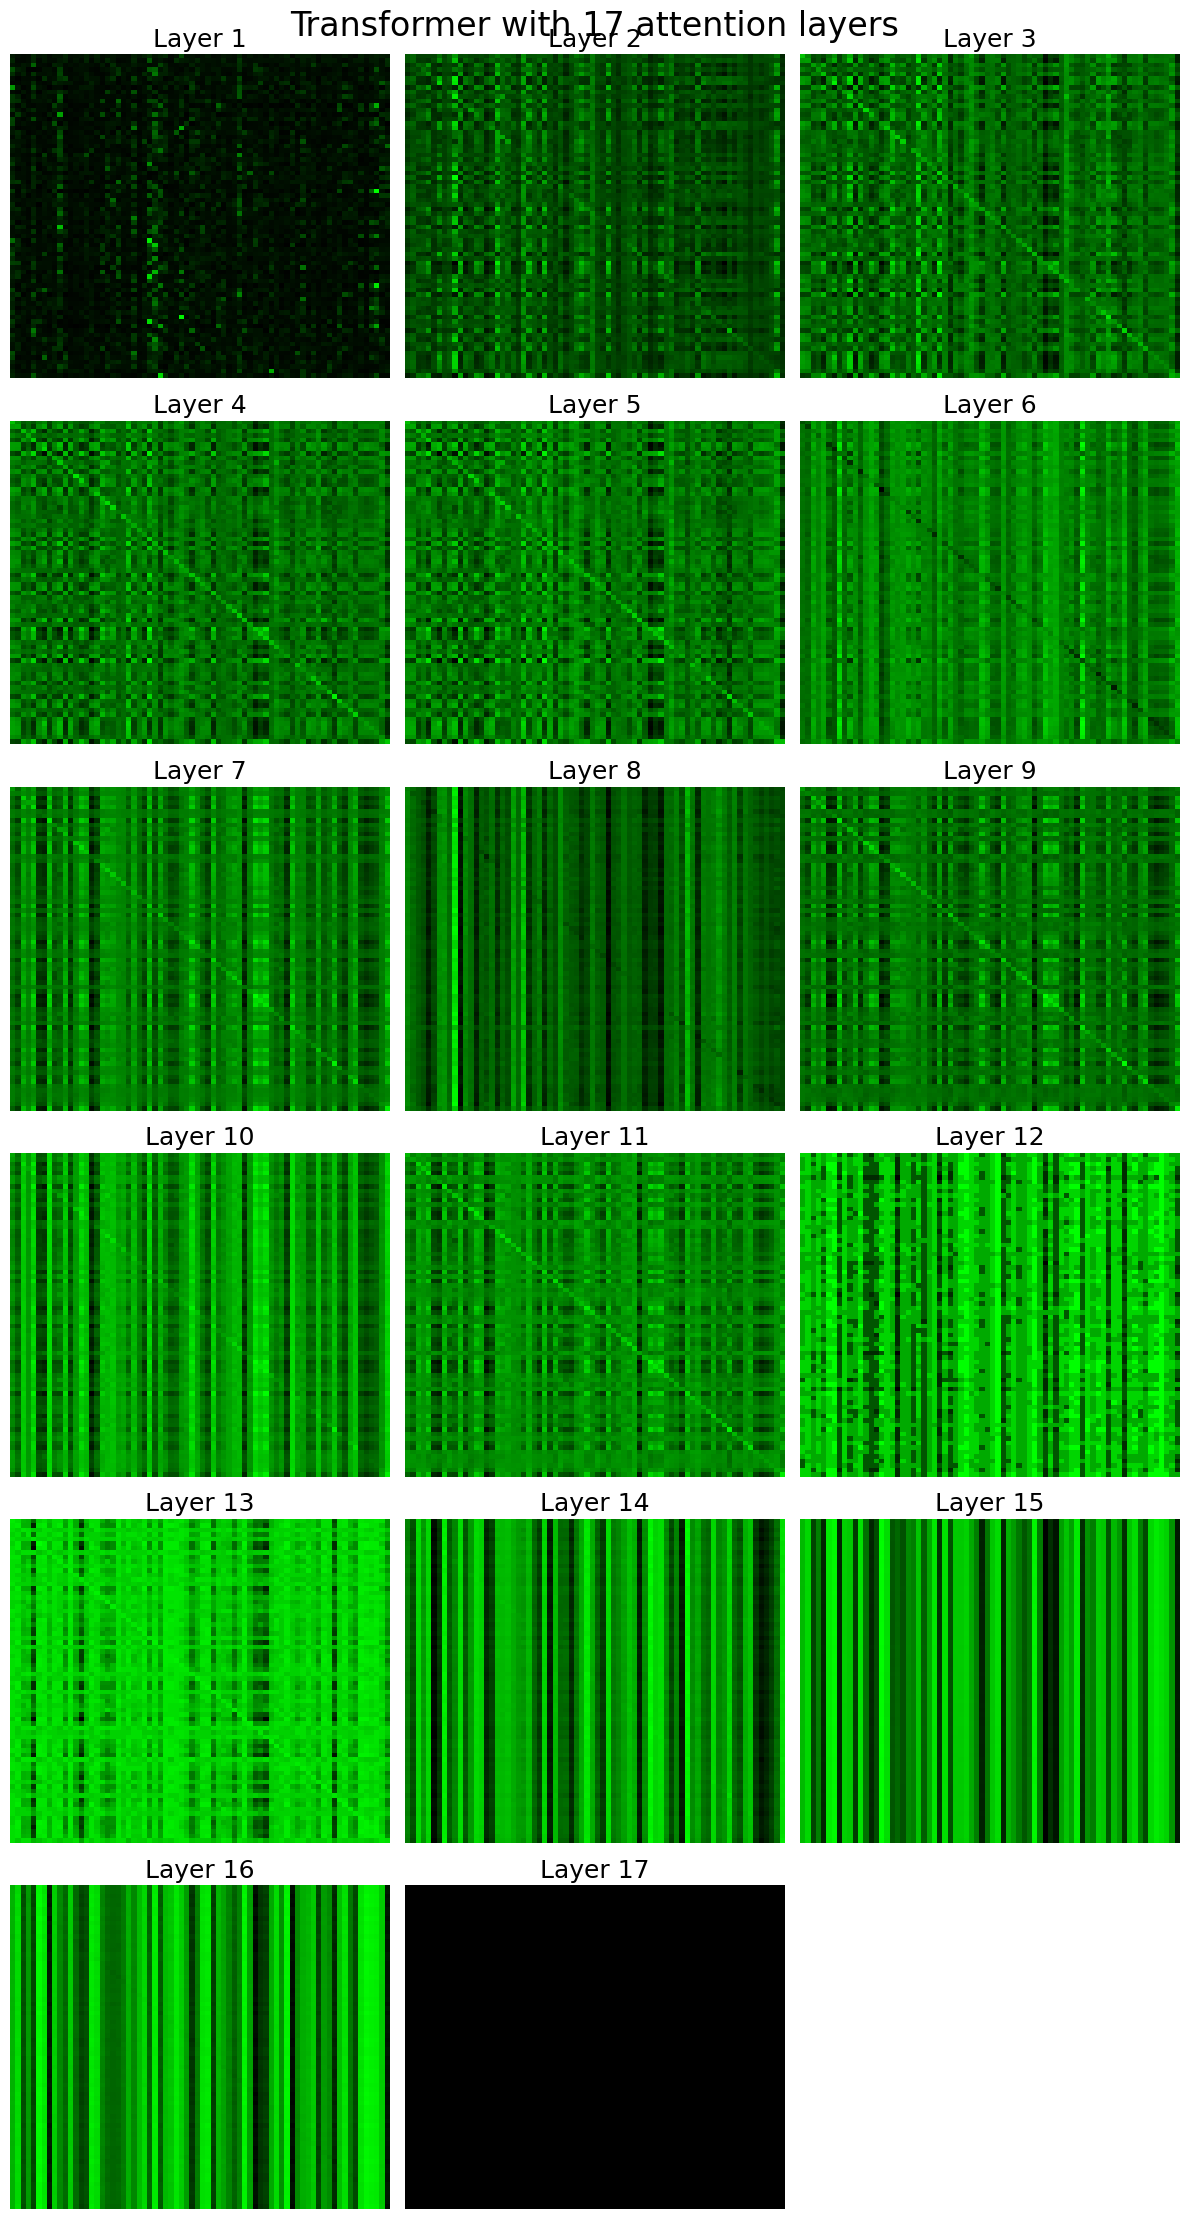

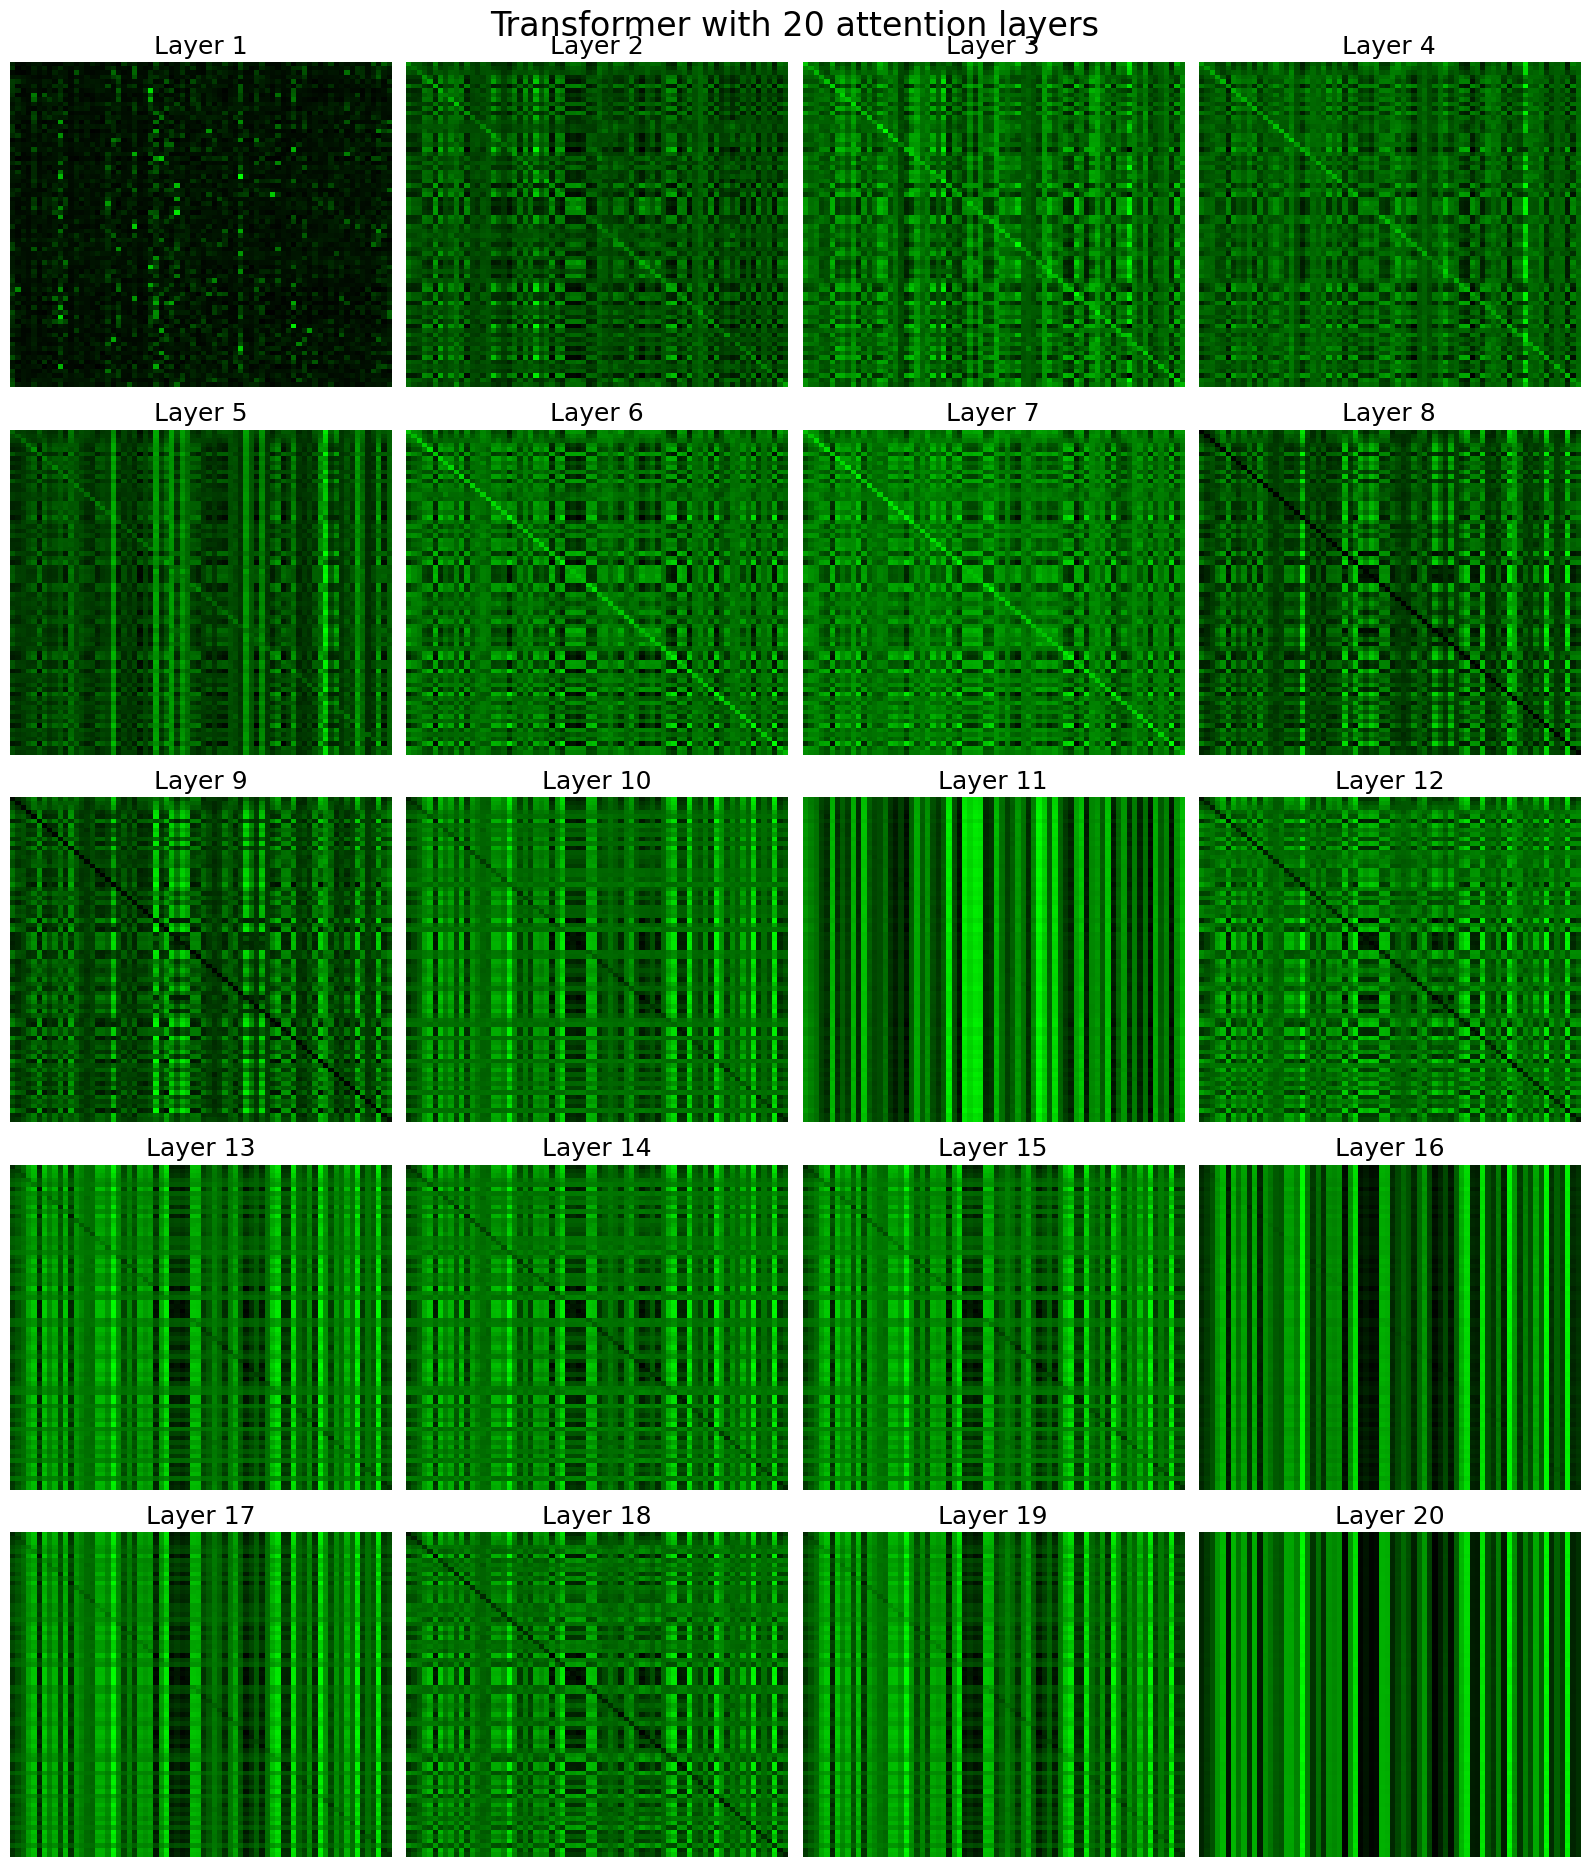

In [6]:
N_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]

subplot_dict = {"3layers": [1, 3], "5layers": [2, 3], "7layers": [3, 3],
                "9layers": [3, 3], "11layers": [3, 4], "13layers": [5, 3],
                "15layers": [5, 3], "17layers": [6, 3], "20layers": [5, 4]}
    
subplot_size = {"3layers": (12, 4.6), "5layers": (12, 8.2), "7layers": (12, 11.8),
                "9layers": (12, 11.8), "11layers": (16, 11.8), "13layers": (12, 19),
                "15layers": (12, 19),  "17layers": (12, 22.6), "20layers": (16, 19)}

cmap_attn = LinearSegmentedColormap.from_list("black_green",
                                                  ["black", "#00FF00"])    

for layer in N_LAYERS:
    with open(ROLL_LOC / f"{layer}layers/attn_matrices{layer}layers.pkl", "rb") as f:
        attn_matrices = pickle.load(f)
    
    attn_list = [np.mean(attn_matrices[key]['attn_matrix'], axis=0) 
                 for key in attn_matrices.keys()]
           
    n_rows = subplot_dict[f"{layer}layers"][0]
    n_cols = subplot_dict[f"{layer}layers"][1]
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=subplot_size[f"{layer}layers"])
    axes = axes.flatten()      
    
    for i, attn_matrix in enumerate(attn_list):
        matrix = attn_matrix.copy()
        # np.fill_diagonal(matrix, 0)
        # matrix = sparsify_global_percentile(matrix, q=60, keep_diagonal=True)
        
        im = axes[i].imshow(matrix, aspect='auto', cmap=cmap_attn)
        axes[i].set_title(f"Layer {i+1}", fontsize=18)
        axes[i].axis('off')
    
        # fig.colorbar(im, ax=axes[i])
    
    # Hide unused subplots if attn_list has fewer than 20 elements
    for j in range(len(attn_list), len(axes)):
        axes[j].axis('off')

    plt.suptitle(f"Transformer with {layer} attention layers", fontsize=24)
    plt.savefig(FIG_DIR / f"{layer}layers/attn_matrices_{layer}layers.pdf", 
                bbox_inches="tight")
    
    plt.tight_layout()
    plt.show()

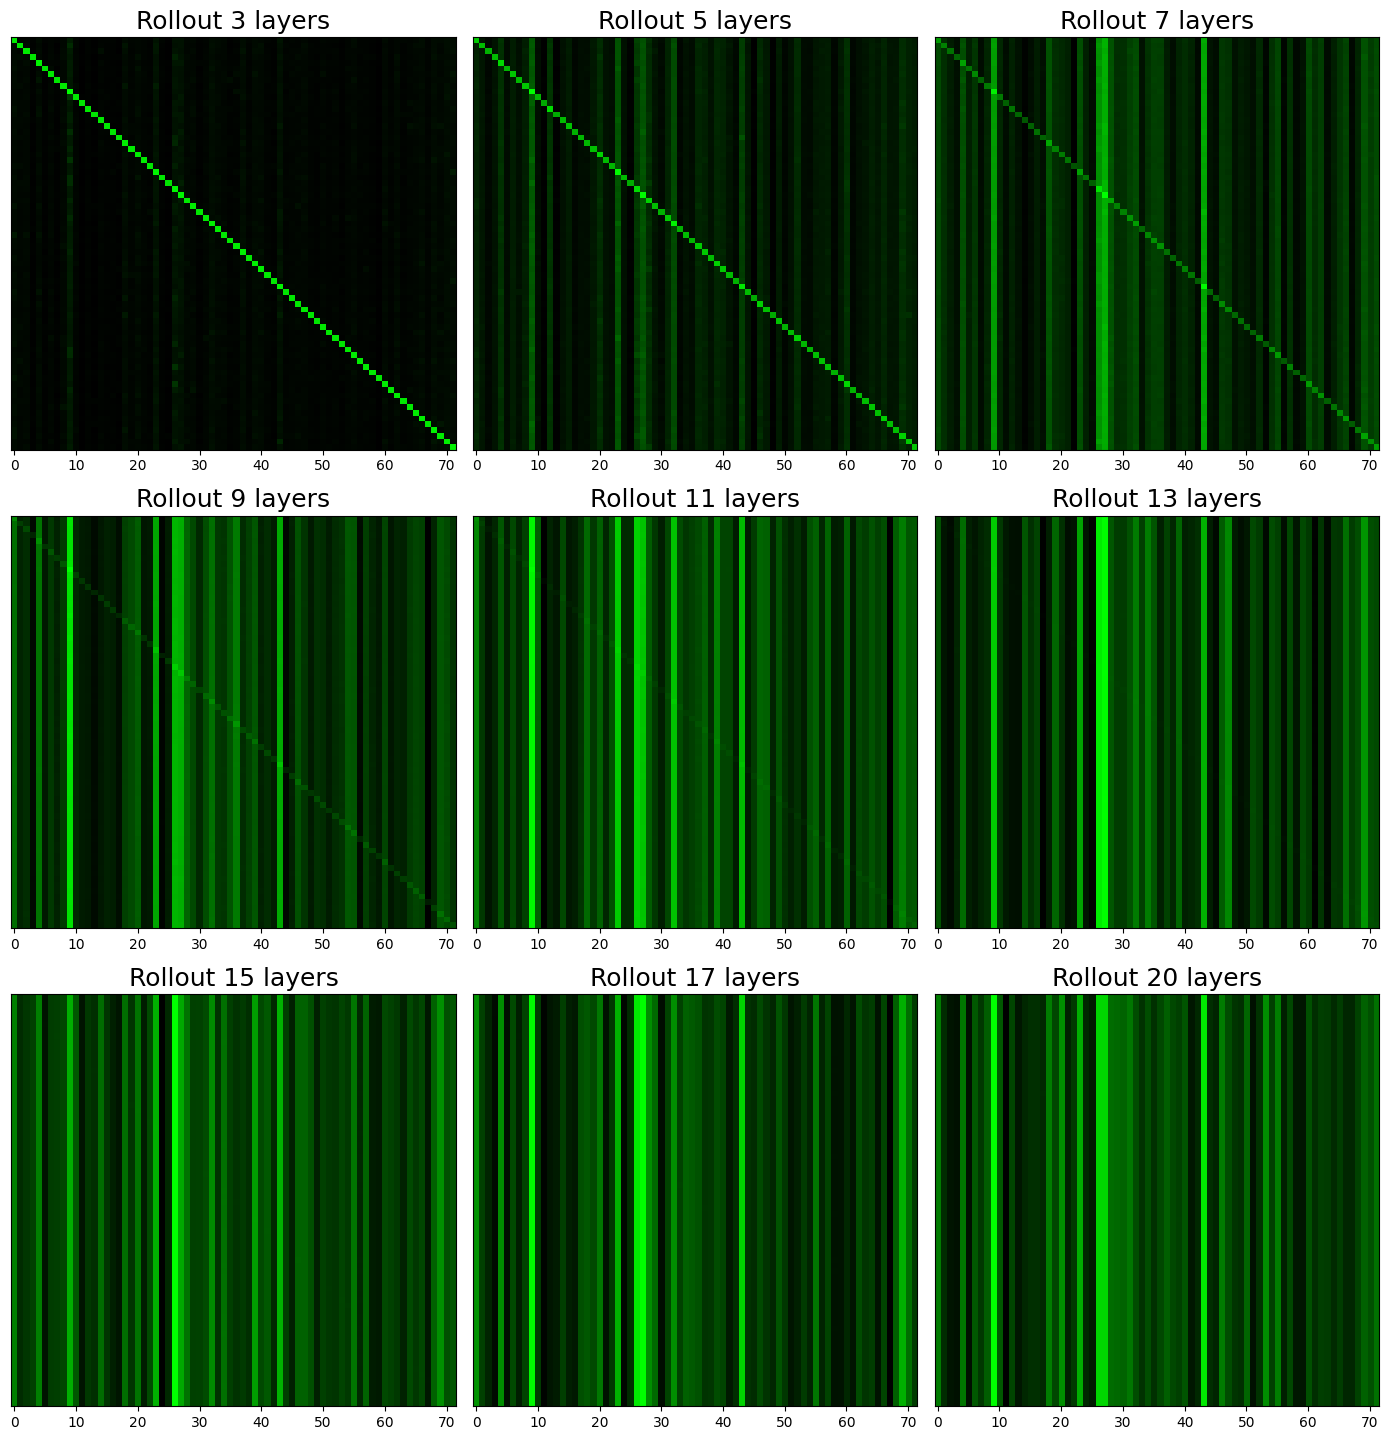

In [7]:
# ROLL_DIR = Path("Results/rollout_global")
N_LAYERS = [3, 5, 7, 9, 11, 13, 15, 17, 20]
# N_LAYERS = 11 

fig, axes = plt.subplots(3, 3, figsize=(14, 14.5))
axes = axes.flatten()

for i, layer in enumerate(N_LAYERS):
    results_rollout = np.load(ROLL_GLOB / f"{layer}layers/rollout{layer}layers.npz")

    R = results_rollout['rollout']
    # np.fill_diagonal(R, 0)
    # R = sparsify_global_percentile(R, q=90, keep_diagonal=True)
    
    # plt.figure(figsize=(10, 11))
    axes[i].imshow(R, aspect='auto', cmap=cmap_attn)
    axes[i].set_title(f"Rollout {layer} layers", fontsize=18)
    
    # plt.title("Attention rollout", fontsize=38, pad=10)   
    
    # axes[i].set_xticks(ticks=np.arange(len(feature_abbrev)),
    #            labels=feature_abbrev,
    #            rotation=90,
    #            fontsize=11)
    
    # plt.xticks(ticks=indices_R,
    #            labels=lst_plot_R,
    #            rotation=90,
    #            fontsize=18)

    axes[i].set_yticks([])

plt.tight_layout()
plt.savefig(FIG_DIR / "attention_rollout_all_layers.pdf", bbox_inches="tight")
plt.show()

### Video

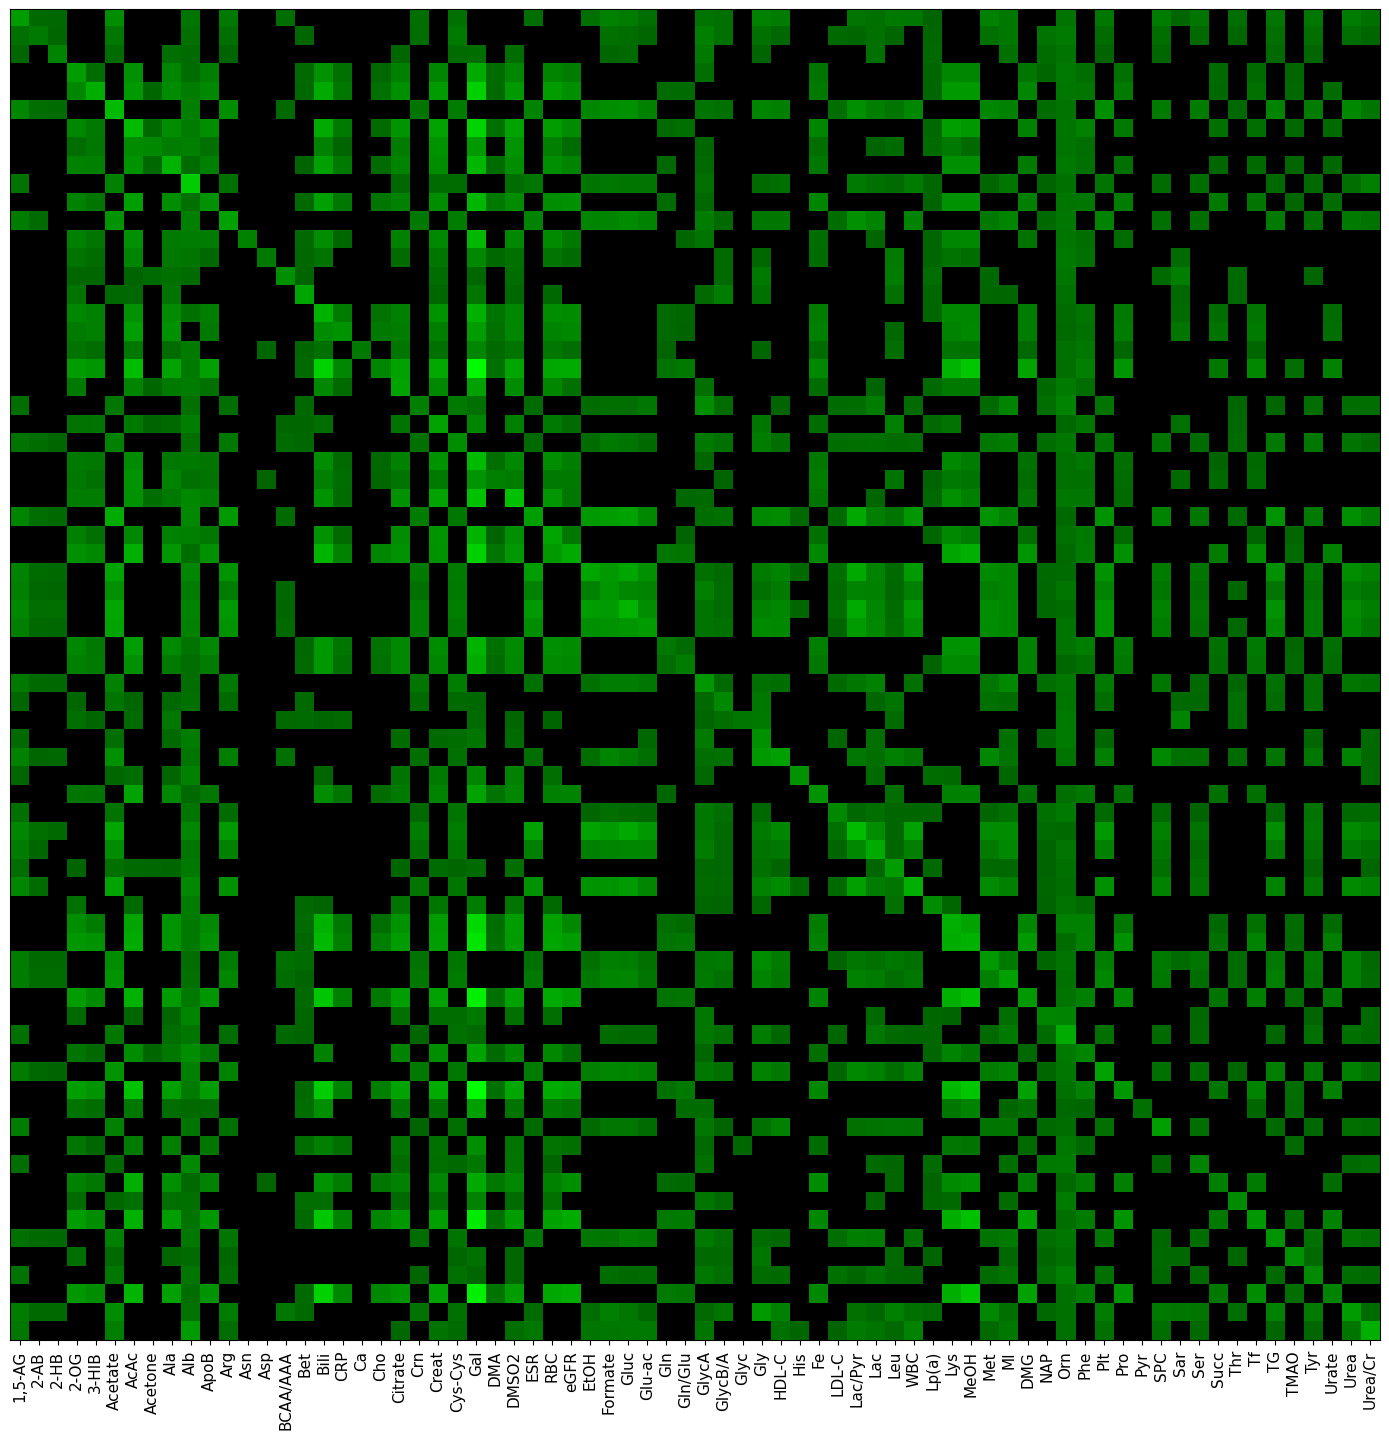

In [8]:
M = attn_list[1]
# np.fill_diagonal(R, 0)
M = sparsify_global_percentile(M, q=60, keep_diagonal=True)

# plt.figure(figsize=(10, 11))
plt.figure(figsize=(14, 14.5))
im = plt.imshow(M, aspect='auto', cmap=cmap_attn)

# plt.title("Attention rollout", fontsize=38, pad=10)   

plt.xticks(ticks=np.arange(len(feature_abbrev)),
           labels=feature_abbrev,
           rotation=90,
           fontsize=11)

# plt.xticks(ticks=indices_R,
#            labels=lst_plot_R,
#            rotation=90,
#            fontsize=18)

plt.yticks([])

plt.tight_layout()
# plt.savefig(f"Results/attention_rollout_{N_LAYERS}layers.pdf", bbox_inches="tight")
plt.show()

In [9]:
for i, m in enumerate(attn_list):
    print(f"Layer {i+1}:", np.sum(m[:,9]))

print("Rolout:", np.sum(R[:,9]))

Layer 1: 1.9443774
Layer 2: 1.257293
Layer 3: 1.2081616
Layer 4: 1.0678296
Layer 5: 1.0166636
Layer 6: 1.0019705
Layer 7: 1.0021207
Layer 8: 0.9859535
Layer 9: 1.0213554
Layer 10: 0.9821181
Layer 11: 1.001646
Layer 12: 0.99898124
Layer 13: 0.99991655
Layer 14: 0.9989438
Layer 15: 0.9999596
Layer 16: 0.870229
Layer 17: 0.9825886
Layer 18: 0.9999745
Layer 19: 0.99157846
Layer 20: 0.92641646
Rolout: 1.5837492


In [10]:
import numpy as np
import matplotlib.pyplot as plt

def plot_avg_rollout_column_distributions(
    rollout_avg,
    feature_names,
    top_k=8,
    title="Column-wise structure of averaged rollout matrix",
):
    """
    rollout_avg:
        averaged rollout matrix
        shape [d, d]
    """

    d = rollout_avg.shape[0]

    # Column importance
    col_scores = rollout_avg.sum(axis=0)

    # Normalize for readability
    # col_scores = col_scores / col_scores.sum()

    # Leaders = dominant columns
    top_idx = np.argsort(col_scores)[-top_k:][::-1]
    top_names = [feature_names[i] for i in top_idx]

    # Distribution of values inside each dominant column
    data = [rollout_avg[:, j] for j in top_idx]

    plt.figure(figsize=(10, 5))

    plt.boxplot(
        data,
        labels=top_names,
        showfliers=False,
    )

    plt.xticks(rotation=60, ha="right")
    plt.ylabel(r"Rollout values $\bar R_{ij}$")
    plt.title(title)

    plt.tight_layout()
    plt.savefig(f"Results/test_plot.pdf", bbox_inches="tight")
    plt.show()

    return top_idx, top_names, col_scores

/tmp/ipykernel_155523/1957732387.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


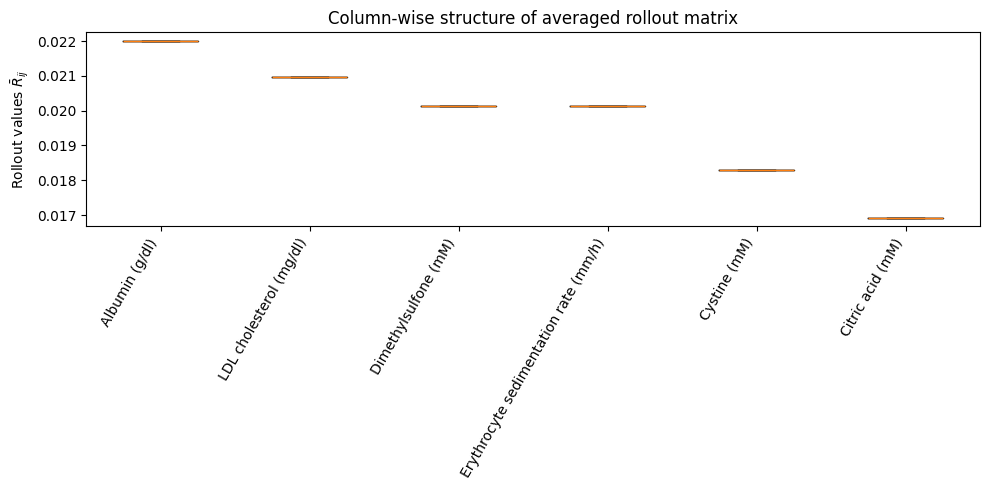

In [11]:
top_idx, top_names, col_scores = plot_avg_rollout_column_distributions(
    rollout_avg=R,
    feature_names=feature_names,
    top_k=6,
)

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_rollout_leader_columns(rollout_avg, feature_names, top_k=12):
    col_scores = rollout_avg.sum(axis=0)
    # col_scores = col_scores / col_scores.sum()

    top_idx = np.argsort(col_scores)[-top_k:][::-1]
    top_names = [feature_names[i] for i in top_idx]
    top_scores = col_scores[top_idx]

    plt.figure(figsize=(9, 5))
    plt.bar(range(top_k), top_scores)
    plt.xticks(range(top_k), top_names, rotation=60, ha="right")
    plt.ylabel("Normalized rollout column sum")
    plt.title("Dominant columns of the averaged rollout matrix")
    plt.tight_layout()
    plt.show()

    return top_idx, top_names, top_scores

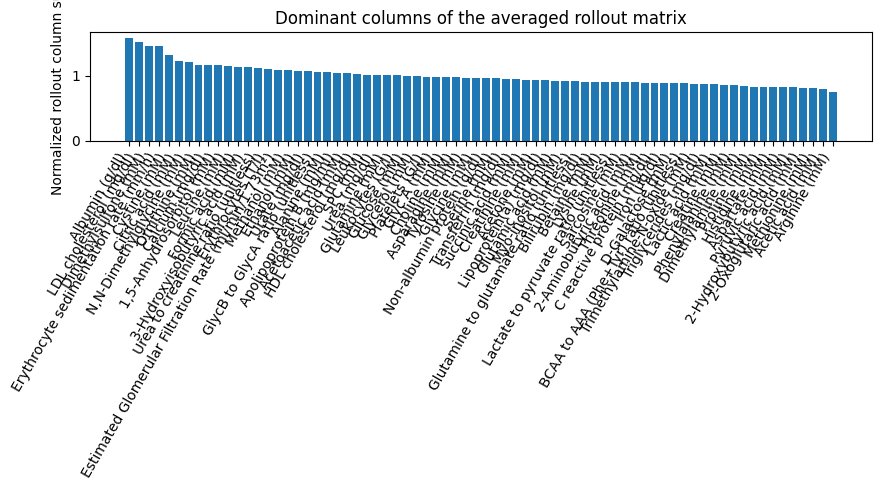

In [13]:
top_idx, top_names, top_scores = plot_rollout_leader_columns(
    rollout_avg=R,
    feature_names=feature_names,
    top_k=72,
)